In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
 DATA_DIR = "ml-1m"

In [3]:
# Users: userId, gender, age, occupation, zip
users = pd.read_csv(
    f"{DATA_DIR}/users.dat",
    sep="::",
    engine="python",
    header=None,
    names=["user_id", "gender", "age", "occupation", "zip"]
)
users.head()

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


## Constructing the user–movie matrix

In [4]:
# Ratings: userId, movieId, rating, timestamp
ratings = pd.read_csv(
    f"{DATA_DIR}/ratings.dat",
    sep="::",
    engine="python",
    header=None,
    names=["user_id", "movie_id", "rating", "timestamp"]
)

In [5]:
# Movies: movieId, title, genres
movies = pd.read_csv(
    f"{DATA_DIR}/movies.dat",
    sep="::",
    engine="python",
    header=None,
    encoding="latin1",
    names=["movie_id", "title", "genres"]
)

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

ratings.head()

Ratings shape: (1000209, 4)
Movies shape: (3883, 3)


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
# Build the user–movie rating matrix

user_movie_matrix = ratings.pivot(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print("User-movie matrix shape:", user_movie_matrix.shape)
user_movie_matrix.iloc[:5, :5]

User-movie matrix shape: (6040, 3706)


movie_id,1,2,3,4,5
user_id,,,,,
1,5.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check sparsity

num_users, num_movies = user_movie_matrix.shape
num_possible_ratings = num_users * num_movies
num_actual_ratings = user_movie_matrix.notna().sum().sum()
sparsity = 1 - (num_actual_ratings / num_possible_ratings)

print(f"Number of users: {num_users}")
print(f"Number of movies: {num_movies}")
print(f"Actual ratings: {num_actual_ratings}")
print(f"Possible ratings: {num_possible_ratings}")
print(f"Sparsity: {sparsity:.4f}")

Number of users: 6040
Number of movies: 3706
Actual ratings: 1000209
Possible ratings: 22384240
Sparsity: 0.9553


In [8]:
ratings_per_user = ratings.groupby("user_id").size()

print("Average ratings per user:", ratings_per_user.mean())
print("Median ratings per user:", ratings_per_user.median())

Average ratings per user: 165.5975165562914
Median ratings per user: 96.0


In [9]:
# Attach movie titles for inspection

movie_id_to_title = dict(zip(movies["movie_id"], movies["title"]))

sample_movie_ids = user_movie_matrix.columns[:10]
sample_titles = [movie_id_to_title[mid] for mid in sample_movie_ids]

for mid, title in zip(sample_movie_ids, sample_titles):
    print(mid, "->", title)

1 -> Toy Story (1995)
2 -> Jumanji (1995)
3 -> Grumpier Old Men (1995)
4 -> Waiting to Exhale (1995)
5 -> Father of the Bride Part II (1995)
6 -> Heat (1995)
7 -> Sabrina (1995)
8 -> Tom and Huck (1995)
9 -> Sudden Death (1995)
10 -> GoldenEye (1995)


## Matrix factorization (SVD)

In [10]:
# Average rating given by each user
user_means = user_movie_matrix.mean(axis=1)

print("User mean ratings:")
print(user_means.head())

User mean ratings:
user_id
1    4.188679
2    3.713178
3    3.901961
4    4.190476
5    3.146465
dtype: float64


In [11]:
# Subtract each user's average rating from their observed ratings
user_movie_centered = user_movie_matrix.sub(user_means, axis=0)

user_movie_centered.iloc[:5, :5]

movie_id,1,2,3,4,5
user_id,,,,,
1,0.811321,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


In [12]:
# Fill missing values after centering
user_movie_filled = user_movie_centered.fillna(0)

user_movie_filled.iloc[:5, :5]

movie_id,1,2,3,4,5
user_id,,,,,
1,0.811321,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0
5,0.000000,0.0,0.0,0.0,0.0


In [13]:
# Fit SVD
n_components = 50

svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(user_movie_filled)
movie_factors = svd.components_

print("User latent matrix shape:", user_factors.shape)

User latent matrix shape: (6040, 50)


In [14]:
# Put user factors into a DataFrame
latent_columns = [f"latent_{i+1}" for i in range(n_components)]

user_factors_df = pd.DataFrame(
    user_factors,
    index=user_movie_filled.index,
    columns=latent_columns
)

user_factors_df.head()

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,...,latent_41,latent_42,latent_43,latent_44,latent_45,latent_46,latent_47,latent_48,latent_49,latent_50
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.187847,0.191394,-0.343151,0.380128,-0.064345,-0.420163,-0.302064,0.110885,-0.194172,0.191309,...,0.158756,-0.041627,-0.176698,0.052925,0.096408,0.029505,0.258307,-0.263752,0.369589,0.007152
2,1.738784,0.914784,-0.403497,1.971573,0.724541,-0.018185,-0.484325,0.074904,-0.637333,0.401950,...,-0.246503,0.010915,0.027832,-0.229039,0.851876,0.220520,0.113954,1.120411,0.770196,0.276451
3,0.433184,0.198682,-0.279560,0.079784,0.760226,-0.108124,0.730650,0.025918,-0.479242,0.633865,...,0.252231,0.003590,-0.021136,0.348671,-0.103480,0.191159,-0.071640,0.150673,-0.318592,0.235119
4,0.083006,-0.351280,-0.203252,0.256200,-0.043909,-0.419595,-0.093279,-0.011786,0.112687,-0.387942,...,0.452257,0.040774,-0.687762,-0.153464,-0.092032,0.147716,-0.504897,-0.086726,0.360582,-0.255256
5,1.792067,-2.823673,2.182608,-0.433383,-0.186491,1.075984,0.347990,0.641784,1.299687,0.438175,...,-0.591706,-0.860563,-0.621698,-2.243503,1.069090,0.640353,0.542057,-0.789063,1.351506,-0.380391


In [15]:
# Check explained variance

explained_variance = svd.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained variance by component:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)
print(f"\nTotal explained variance with {n_components} components: {cumulative_variance[-1]:.4f}")

Explained variance by component:
[0.04283037 0.01647781 0.00975044 0.00832335 0.00766806 0.00702817
 0.00579426 0.00525172 0.00466042 0.00469556 0.0043627  0.00406295
 0.00383385 0.00373983 0.00357202 0.00342683 0.00336289 0.00326199
 0.00312972 0.00308552 0.00297408 0.00289762 0.00284986 0.00281312
 0.00273719 0.00270862 0.00266439 0.00260407 0.00257685 0.00252536
 0.00252342 0.0025038  0.00244697 0.00242656 0.00239924 0.00236279
 0.00233885 0.00230672 0.00228544 0.00227943 0.00223503 0.00221716
 0.00216768 0.00215074 0.00212421 0.00210358 0.0020652  0.00205405
 0.002046   0.00202146]

Cumulative explained variance:
[0.04283037 0.05930818 0.06905862 0.07738197 0.08505003 0.0920782
 0.09787246 0.10312418 0.1077846  0.11248015 0.11684286 0.12090581
 0.12473966 0.12847949 0.13205151 0.13547834 0.13884123 0.14210322
 0.14523294 0.14831847 0.15129254 0.15419016 0.15704002 0.15985314
 0.16259033 0.16529896 0.16796335 0.17056742 0.17314427 0.17566963
 0.17819305 0.18069685 0.18314383 0.18557

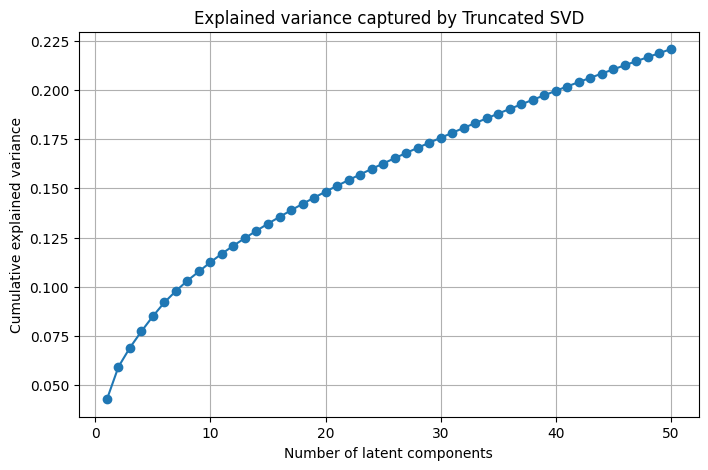

In [16]:
# plot of cumulative variance

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), cumulative_variance, marker='o')
plt.xlabel("Number of latent components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained variance captured by Truncated SVD")
plt.grid(True)
plt.savefig("plots/explained_variance.png", bbox_inches="tight")
plt.show()

In [17]:
users_age = users[["user_id", "age"]]

users_age.head(8)

,user_id,age
0,1,1
1,2,56
2,3,25
3,4,45
4,5,25
5,6,50
6,7,35
7,8,25


In [18]:
data = user_factors_df.reset_index().merge(
    users_age,
    on="user_id",
    how="inner"
)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (6040, 52)


,user_id,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,...,latent_42,latent_43,latent_44,latent_45,latent_46,latent_47,latent_48,latent_49,latent_50,age
0,1,0.187847,0.191394,-0.343151,0.380128,-0.064345,-0.420163,-0.302064,0.110885,-0.194172,...,-0.041627,-0.176698,0.052925,0.096408,0.029505,0.258307,-0.263752,0.369589,0.007152,1
1,2,1.738784,0.914784,-0.403497,1.971573,0.724541,-0.018185,-0.484325,0.074904,-0.637333,...,0.010915,0.027832,-0.229039,0.851876,0.220520,0.113954,1.120411,0.770196,0.276451,56
2,3,0.433184,0.198682,-0.279560,0.079784,0.760226,-0.108124,0.730650,0.025918,-0.479242,...,0.003590,-0.021136,0.348671,-0.103480,0.191159,-0.071640,0.150673,-0.318592,0.235119,25
3,4,0.083006,-0.351280,-0.203252,0.256200,-0.043909,-0.419595,-0.093279,-0.011786,0.112687,...,0.040774,-0.687762,-0.153464,-0.092032,0.147716,-0.504897,-0.086726,0.360582,-0.255256,45
4,5,1.792067,-2.823673,2.182608,-0.433383,-0.186491,1.075984,0.347990,0.641784,1.299687,...,-0.860563,-0.621698,-2.243503,1.069090,0.640353,0.542057,-0.789063,1.351506,-0.380391,25


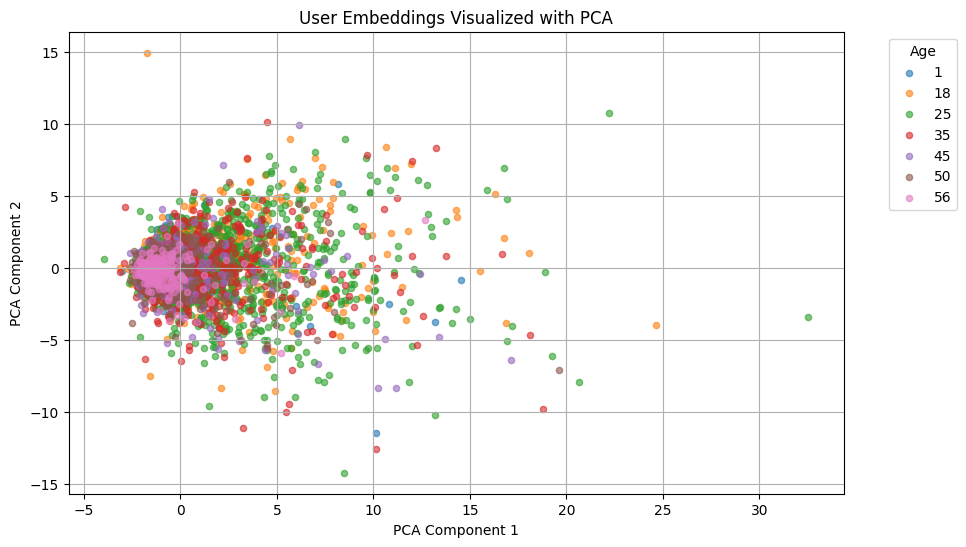

Explained variance ratio: [0.197871   0.07464782]
Total explained variance (2 components): 0.27251882263250105


In [19]:
# latent features only
X_latent = data.drop(['age','user_id'], axis=1)

# --- PCA to 2D ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_latent)

pca_df = pd.DataFrame({
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1],
    "age": data["age"].values
})

plt.figure(figsize=(10, 6))
for age_value in sorted(pca_df["age"].unique()):
    subset = pca_df[pca_df["age"] == age_value]
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=str(age_value),
        alpha=0.6,
        s=20
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("User Embeddings Visualized with PCA")
plt.legend(title="Age", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.savefig("plots/pca.png", bbox_inches="tight")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (2 components):", pca.explained_variance_ratio_.sum())

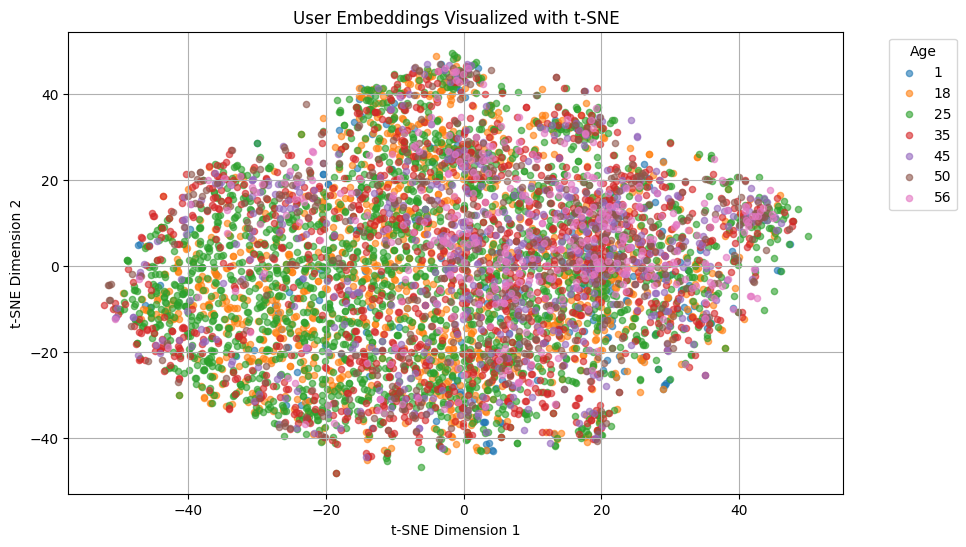

In [20]:
# --- t-SNE to 2D ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_latent)

tsne_df = pd.DataFrame({
    "tsne_1": X_tsne[:, 0],
    "tsne_2": X_tsne[:, 1],
    "age": data["age"].values
})

plt.figure(figsize=(10, 6))
for age_value in sorted(tsne_df["age"].unique()):
    subset = tsne_df[tsne_df["age"] == age_value]
    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        label=str(age_value),
        alpha=0.6,
        s=20
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("User Embeddings Visualized with t-SNE")
plt.legend(title="Age", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.savefig("plots/t_sne.png", bbox_inches="tight")
plt.show()

## Gender Classification

In [21]:
data.columns

Index(['user_id', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'latent_5',
       'latent_6', 'latent_7', 'latent_8', 'latent_9', 'latent_10',
       'latent_11', 'latent_12', 'latent_13', 'latent_14', 'latent_15',
       'latent_16', 'latent_17', 'latent_18', 'latent_19', 'latent_20',
       'latent_21', 'latent_22', 'latent_23', 'latent_24', 'latent_25',
       'latent_26', 'latent_27', 'latent_28', 'latent_29', 'latent_30',
       'latent_31', 'latent_32', 'latent_33', 'latent_34', 'latent_35',
       'latent_36', 'latent_37', 'latent_38', 'latent_39', 'latent_40',
       'latent_41', 'latent_42', 'latent_43', 'latent_44', 'latent_45',
       'latent_46', 'latent_47', 'latent_48', 'latent_49', 'latent_50', 'age'],
      dtype='str')

In [22]:
# Load gender info
users_gender = users[['user_id', 'gender']]

# Merge with embeddings
data_gender = data.merge(users_gender, on='user_id', how='inner')

print("Dataset shape:", data_gender.shape)
data_gender.head()

Dataset shape: (6040, 53)


,user_id,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,...,latent_43,latent_44,latent_45,latent_46,latent_47,latent_48,latent_49,latent_50,age,gender
0,1,0.187847,0.191394,-0.343151,0.380128,-0.064345,-0.420163,-0.302064,0.110885,-0.194172,...,-0.176698,0.052925,0.096408,0.029505,0.258307,-0.263752,0.369589,0.007152,1,F
1,2,1.738784,0.914784,-0.403497,1.971573,0.724541,-0.018185,-0.484325,0.074904,-0.637333,...,0.027832,-0.229039,0.851876,0.220520,0.113954,1.120411,0.770196,0.276451,56,M
2,3,0.433184,0.198682,-0.279560,0.079784,0.760226,-0.108124,0.730650,0.025918,-0.479242,...,-0.021136,0.348671,-0.103480,0.191159,-0.071640,0.150673,-0.318592,0.235119,25,M
3,4,0.083006,-0.351280,-0.203252,0.256200,-0.043909,-0.419595,-0.093279,-0.011786,0.112687,...,-0.687762,-0.153464,-0.092032,0.147716,-0.504897,-0.086726,0.360582,-0.255256,45,M
4,5,1.792067,-2.823673,2.182608,-0.433383,-0.186491,1.075984,0.347990,0.641784,1.299687,...,-0.621698,-2.243503,1.069090,0.640353,0.542057,-0.789063,1.351506,-0.380391,25,M


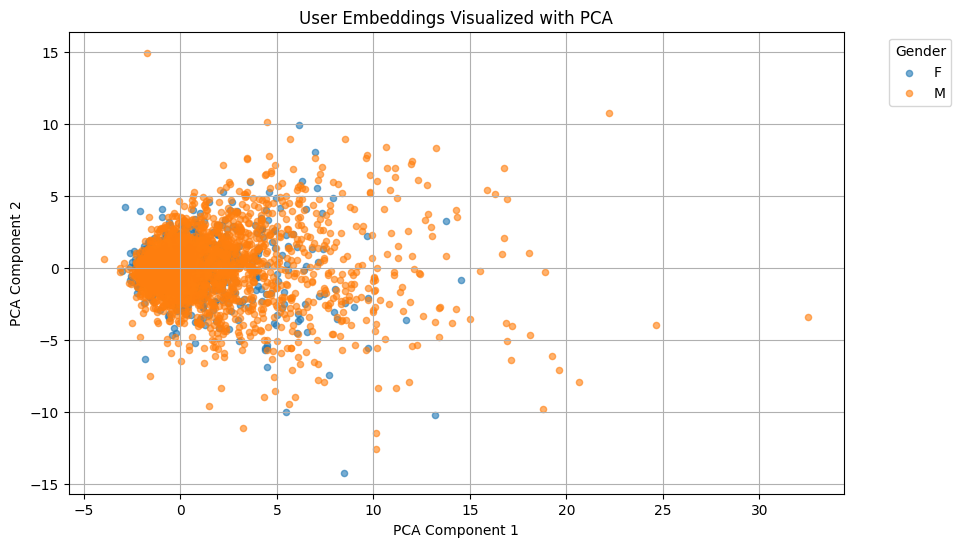

Explained variance ratio: [0.197871   0.07464782]
Total explained variance (2 components): 0.27251882263250105


In [23]:
# latent features only
X = data_gender.drop(['gender', 'user_id', 'age'], axis=1)

# --- PCA to 2D ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1],
    "gender": data_gender["gender"].values
})

plt.figure(figsize=(10, 6))
for gender_value in sorted(pca_df["gender"].unique()):
    subset = pca_df[pca_df["gender"] == gender_value]
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=str(gender_value),
        alpha=0.6,
        s=20
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("User Embeddings Visualized with PCA")
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.savefig("plots/pca_gender.png", bbox_inches="tight")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (2 components):", pca.explained_variance_ratio_.sum())

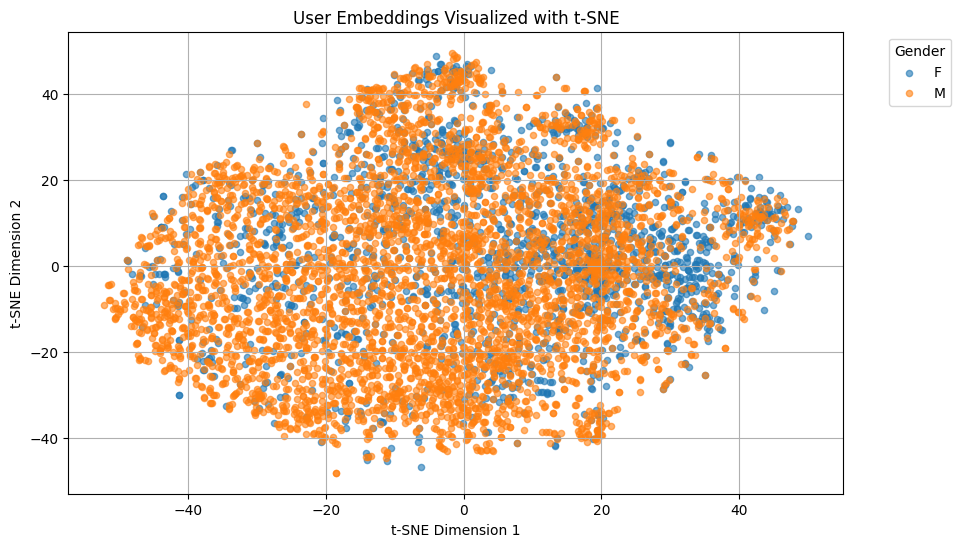

In [24]:
# --- t-SNE to 2D ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame({
    "tsne_1": X_tsne[:, 0],
    "tsne_2": X_tsne[:, 1],
    "gender": data_gender["gender"].values
})

plt.figure(figsize=(10, 6))
for gender_value in sorted(tsne_df["gender"].unique()):
    subset = tsne_df[tsne_df["gender"] == gender_value]
    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        label=str(gender_value),
        alpha=0.6,
        s=20
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("User Embeddings Visualized with t-SNE")
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.savefig("plots/t_sne_gender.png", bbox_inches="tight")
plt.show()

In [25]:
# Features = latent embeddings

# Target = gender (convert to 0/1)
y = data_gender['gender'].map({'M': 0, 'F': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Accuracy: 0.7698675496688742

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.93      0.85       866
           1       0.68      0.35      0.47       342

    accuracy                           0.77      1208
   macro avg       0.73      0.64      0.66      1208
weighted avg       0.76      0.77      0.74      1208



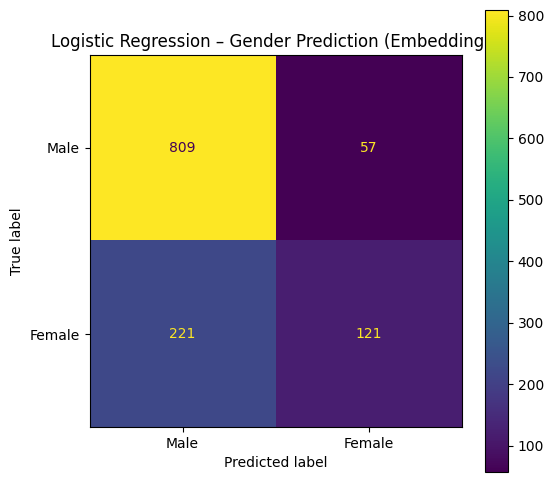

In [26]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

labels = [0, 1]
display_labels = ['Male', 'Female']

cm = confusion_matrix(y_test, y_pred_lr, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)

ax.set_title("Logistic Regression – Gender Prediction (Embeddings)")
plt.savefig("plots/lr_gender_embedding.png", bbox_inches="tight")
plt.show()

Random Forest Accuracy: 0.7533112582781457

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.96      0.85       866
           1       0.71      0.22      0.33       342

    accuracy                           0.75      1208
   macro avg       0.73      0.59      0.59      1208
weighted avg       0.74      0.75      0.70      1208



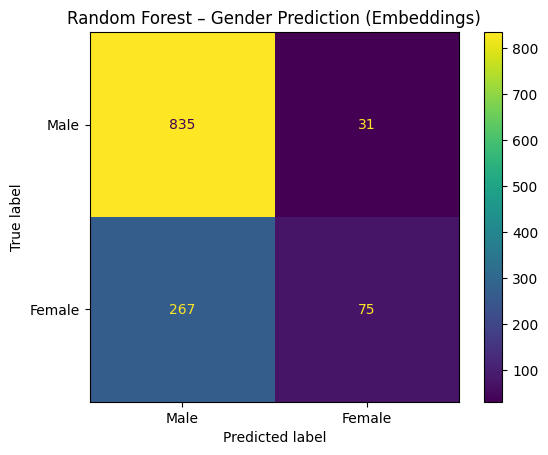

In [27]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot()

plt.title("Random Forest – Gender Prediction (Embeddings)")
plt.savefig("plots/rf_gender_embedding.png", bbox_inches="tight")
plt.show()

In [28]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
4,latent_5,0.082761
0,latent_1,0.039308
3,latent_4,0.034169
5,latent_6,0.029611
23,latent_24,0.027326
2,latent_3,0.025991
14,latent_15,0.025695
10,latent_11,0.024723
13,latent_14,0.022321
16,latent_17,0.019651


In [29]:
# Find top movies per latent feature

# pick a latent dimension
latent_idx = 4

# get weights for all movies
movie_weights = movie_factors[latent_idx]

# get top movies (both positive and negative)
top_pos_idx = np.argsort(movie_weights)[-10:][::-1]
top_neg_idx = np.argsort(movie_weights)[:10]

In [30]:
movie_ids = user_movie_matrix.columns

print("Top positive movies for latent_5:")
for idx in top_pos_idx:
    mid = movie_ids[idx]
    print(movie_id_to_title[mid])

print("\nTop negative movies for latent_5:")
for idx in top_neg_idx:
    mid = movie_ids[idx]
    print(movie_id_to_title[mid])

Top positive movies for latent_5:
Star Wars: Episode IV - A New Hope (1977)
Star Wars: Episode V - The Empire Strikes Back (1980)
Raiders of the Lost Ark (1981)
Godfather, The (1972)
Matrix, The (1999)
Terminator, The (1984)
Blade Runner (1982)
Alien (1979)
Godfather: Part II, The (1974)
Aliens (1986)

Top negative movies for latent_5:
Shakespeare in Love (1998)
Clueless (1995)
Full Monty, The (1997)
Pleasantville (1998)
When Harry Met Sally... (1989)
Thelma & Louise (1991)
Beauty and the Beast (1991)
Little Mermaid, The (1989)
Breakfast Club, The (1985)
Truman Show, The (1998)


The interpretation of the most important latent feature (latent_5) reveals a clear and intuitive preference axis. On one side, users with high values on this dimension tend to favor action, science fiction, and crime classics such as *Star Wars*, *The Matrix*, *The Godfather*, and *Terminator*. On the opposite side, users are associated with romance, family-oriented, and lighter drama films such as *Clueless*, *The Little Mermaid*, and *When Harry Met Sally*.

Interestingly, this pattern closely mirrors the results obtained from explicit genre-based features, where Romance and Action emerged as the most important predictors. In this sense, the latent embeddings do not contradict the earlier findings, but rather recover a very similar structure in a more implicit way.

This suggests that the matrix factorization approach successfully captures meaningful and interpretable preference patterns, even without explicitly using genre information.

### Gender Prediction: Genre Features vs Embeddings

We compared two approaches for gender prediction:

* Handcrafted behavioral & genre-based features (Stage 1)
* Latent user embeddings from matrix factorization (Stage 2)

Both approaches achieved similar overall accuracy in the range of **~75–78%**, slightly above the majority-class baseline (~72%).

However, the models show a consistent pattern:

* All models perform **very well on the majority class (male users)**
* Performance on the minority class (female users) is significantly lower, especially in terms of recall

Using embeddings did not significantly improve overall accuracy compared to handcrafted features. However:

* Embeddings achieved slightly better ROC-AUC (~0.80), suggesting they capture meaningful preference structure
* Logistic Regression on embeddings provided the **most balanced performance** among tested models

Overall, the results suggest that:

> User rating behavior contains some signal for gender prediction, but it is relatively weak and heavily influenced by class imbalance.

## Age Classification

In [31]:
# try 4 classes
def map_age(age):
    if age in [1, 18]:
        return "under_25"
    elif age == 25:
        return "25-34"
    elif age == 35:
        return "35-44"
    else:
        return "45_plus"

In [32]:
data["age_group"] = data["age"].apply(map_age)

print("Age group distribution:")
print(data["age_group"].value_counts())

Age group distribution:
age_group
25-34       2096
45_plus     1426
under_25    1325
35-44       1193
Name: count, dtype: int64


In [33]:
X = data[latent_columns]
y = data["age_group"]

In [34]:
print("Age distribution:")
print(y.value_counts().sort_index())

Age distribution:
age_group
25-34       2096
35-44       1193
45_plus     1426
under_25    1325
Name: count, dtype: int64


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.5190397350993378
              precision    recall  f1-score   support

       25-34       0.51      0.69      0.59       419
       35-44       0.46      0.13      0.21       239
     45_plus       0.48      0.67      0.56       285
    under_25       0.64      0.43      0.52       265

    accuracy                           0.52      1208
   macro avg       0.53      0.48      0.47      1208
weighted avg       0.52      0.52      0.49      1208



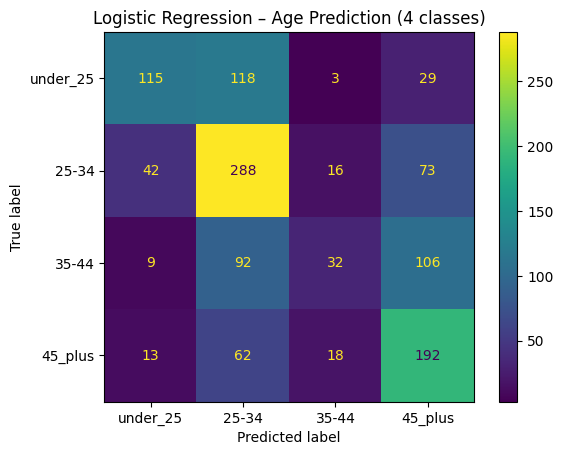

In [37]:
log_reg = LogisticRegression(
    max_iter=500
)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

labels = ['under_25', '25-34', '35-44', '45_plus']

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Logistic Regression – Age Prediction (4 classes)")
plt.savefig("plots/lr_4classes.png", bbox_inches="tight")
plt.show()

Random Forest Accuracy: 0.48509933774834435
              precision    recall  f1-score   support

       25-34       0.46      0.79      0.58       419
       35-44       0.38      0.05      0.10       239
     45_plus       0.48      0.56      0.52       285
    under_25       0.66      0.32      0.43       265

    accuracy                           0.49      1208
   macro avg       0.50      0.43      0.41      1208
weighted avg       0.49      0.49      0.44      1208



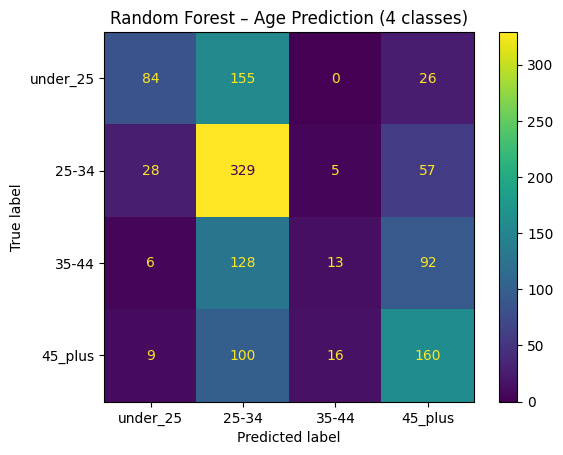

In [38]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Random Forest – Age Prediction (4 classes)")
plt.savefig("plots/rf_4classes.png", bbox_inches="tight")
plt.show()

In [39]:
# merge middle age

def map_age_3(age):
    if age in [1, 18]:
        return "under_25"
    elif age in [25, 35]:
        return "25-44"
    else:
        return "45_plus"

In [40]:
data["age_group"] = data["age"].apply(map_age_3)

print("Age group distribution:")
print(data["age_group"].value_counts())

Age group distribution:
age_group
25-44       3289
45_plus     1426
under_25    1325
Name: count, dtype: int64


In [41]:
X = data[latent_columns]
y = data["age_group"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
# scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.6241721854304636
              precision    recall  f1-score   support

       25-44       0.62      0.85      0.72       658
     45_plus       0.58      0.37      0.45       285
    under_25       0.71      0.34      0.46       265

    accuracy                           0.62      1208
   macro avg       0.64      0.52      0.54      1208
weighted avg       0.63      0.62      0.60      1208



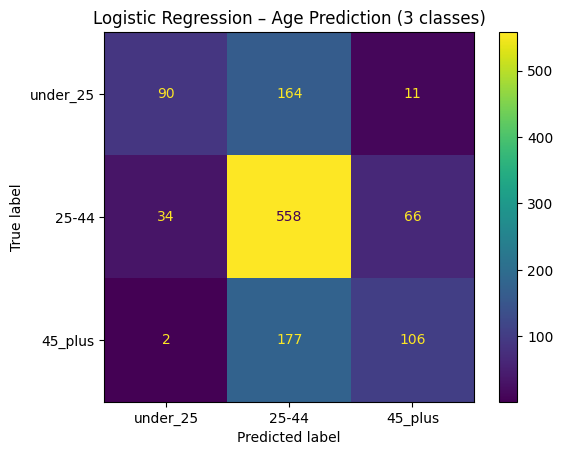

In [44]:
log_reg = LogisticRegression(
    max_iter=500
)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

labels = ['under_25', '25-44', '45_plus']

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Logistic Regression – Age Prediction (3 classes)")
plt.savefig("plots/lr_3classes_embedding1.png", bbox_inches="tight")
plt.show()

Random Forest Accuracy: 0.5877483443708609
              precision    recall  f1-score   support

       25-44       0.58      0.93      0.71       658
     45_plus       0.59      0.18      0.28       285
    under_25       0.75      0.18      0.29       265

    accuracy                           0.59      1208
   macro avg       0.64      0.43      0.43      1208
weighted avg       0.62      0.59      0.52      1208



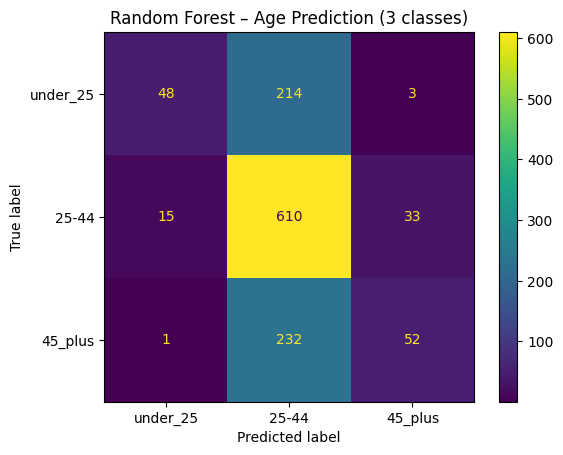

In [45]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Random Forest – Age Prediction (3 classes)")
plt.savefig("plots/rf_3classes_embedding1.png", bbox_inches="tight")
plt.show()

In [46]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
2,latent_3,0.063261
10,latent_11,0.032196
7,latent_8,0.027636
0,latent_1,0.027133
9,latent_10,0.025763
17,latent_18,0.025310
1,latent_2,0.024466
12,latent_13,0.023304
20,latent_21,0.020906
18,latent_19,0.020726


In [47]:
# Find top movies per latent feature

# pick a latent dimension
latent_idx = 2

# get weights for all movies
movie_weights = movie_factors[latent_idx]

# get top movies (both positive and negative)
top_pos_idx = np.argsort(movie_weights)[-10:][::-1]
top_neg_idx = np.argsort(movie_weights)[:10]

In [48]:
movie_ids = user_movie_matrix.columns

print("Top positive movies for latent_3:")
for idx in top_pos_idx:
    mid = movie_ids[idx]
    print(movie_id_to_title[mid])

print("\nTop negative movies for latent_3:")
for idx in top_neg_idx:
    mid = movie_ids[idx]
    print(movie_id_to_title[mid])

Top positive movies for latent_3:
American Beauty (1999)
Fight Club (1999)
Being John Malkovich (1999)
Pulp Fiction (1994)
Matrix, The (1999)
Clerks (1994)
South Park: Bigger, Longer and Uncut (1999)
Reservoir Dogs (1992)
Usual Suspects, The (1995)
Big Lebowski, The (1998)

Top negative movies for latent_3:
Casablanca (1942)
Wizard of Oz, The (1939)
African Queen, The (1951)
It's a Wonderful Life (1946)
Gone with the Wind (1939)
E.T. the Extra-Terrestrial (1982)
Butch Cassidy and the Sundance Kid (1969)
North by Northwest (1959)
Some Like It Hot (1959)
Maltese Falcon, The (1941)


The interpretation of another latent feature (latent_3) reveals a generational preference axis. On one side, users are associated with more modern, unconventional films such as *Fight Club*, *Pulp Fiction*, *The Big Lebowski*, and *Being John Malkovich*. On the opposite side, the feature is dominated by classic Hollywood films such as *Casablanca*, *The Wizard of Oz*, *Gone with the Wind*, and *North by Northwest*.

Such patterns are relevant for age prediction, as they align with generational exposure to different periods of film history, further illustrating how latent embeddings encode deeper behavioral signals beyond explicit genre features.

### Latent Preference Modeling: Summary

User preferences were represented using **latent embeddings obtained from matrix factorization (Truncated SVD)** of the user–movie rating matrix. Empirically, **~50 latent components** provided the more or less optimal setting. 

Age prediction from embeddings achieved approximately:

| Task      | Logistic Regression | Random Forest |
| --------- | ------------------- | ------------- |
| 4 classes | ~0.52               | ~0.49         |
| 3 classes | ~0.62               | ~0.59         |

* Both models produced **very similar performance**, indicating that most predictive structure in the embedding space is largely linear.
* The **25–44 age group is predicted most reliably**, which is likely influenced by it being the **largest class in the dataset**.

#### Comparison with genre-based features (Stage 1)

In the first stage of the project, age prediction relied on **genre preference features** derived from users’ rating histories. Using these features, the models achieved relatively modest performance. For the five-class problem, Logistic Regression reached roughly **0.34 accuracy**, while Random Forest achieved about **0.36**. When the task was simplified to three age groups, performance improved somewhat, with Logistic Regression reaching around **0.45 accuracy** and Random Forest about **0.54**.

In comparison, the **latent embeddings learned through matrix factorization produce consistently stronger results**. Using these representations, accuracy for the multi-class setting increased to approximately **0.52**, representing a substantial improvement over the genre-based approach. For the simplified three-class problem, performance further improved to roughly **0.59–0.62**, again outperforming the models trained on genre features alone.

These results suggest that **latent collaborative filtering representations capture patterns in user behavior that are not fully expressed by explicit genre preferences**, making them more informative for demographic prediction tasks.

#### What next?

At the same time, the two feature representations describe **different levels of user preference**: genre features encode explicit content categories, while latent embeddings capture implicit behavioral patterns learned from the rating matrix. Because these representations are likely **complementary rather than redundant**, the final step of the project explores whether combining **genre features and latent embeddings** can further improve demographic prediction performance.


## Genre feature engineering

### Step 1 — Rebuild Rating Behavior Features

In [49]:
user_rating_stats = ratings.groupby("user_id").agg(
    rating_count=("rating", "count"),
    mean_rating=("rating", "mean"),
    std_rating=("rating", "std")
)

pct_5 = ratings.assign(is5=(ratings.rating == 5)).groupby("user_id")["is5"].mean()
pct_1 = ratings.assign(is1=(ratings.rating == 1)).groupby("user_id")["is1"].mean()

user_rating_stats["pct_5"] = pct_5
user_rating_stats["pct_1"] = pct_1

user_rating_stats.head()

,rating_count,mean_rating,std_rating,pct_5,pct_1
user_id,,,,,
1,53,4.188679,0.680967,0.339623,0.000000
2,129,3.713178,1.001513,0.263566,0.015504
3,51,3.901961,0.984985,0.294118,0.019608
4,21,4.190476,1.077917,0.476190,0.047619
5,198,3.146465,1.132699,0.106061,0.095960


### Step 2 — Rebuild Genre Indicator Features

In [50]:
genre_dummies = movies["genres"].str.get_dummies("|")
movie_genres = pd.concat([movies[["movie_id"]], genre_dummies], axis=1)

movie_genres.head()

,movie_id,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [51]:
ratings_genres = ratings.merge(movie_genres, on="movie_id")

In [52]:
genre_cols = genre_dummies.columns

user_genre_counts = ratings_genres.groupby("user_id")[genre_cols].sum()

user_genre_pct = user_genre_counts.div(user_rating_stats["rating_count"], axis=0)

user_genre_pct.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,
1,0.094340,0.094340,0.339623,0.377358,0.264151,0.037736,0.000000,0.396226,0.056604,0.000000,0.000000,0.264151,0.000000,0.113208,0.056604,0.056604,0.037736,0.000000
2,0.434109,0.147287,0.000000,0.000000,0.193798,0.093023,0.000000,0.612403,0.007752,0.007752,0.015504,0.000000,0.023256,0.186047,0.131783,0.240310,0.116279,0.023256
3,0.450980,0.490196,0.058824,0.058824,0.588235,0.000000,0.000000,0.156863,0.039216,0.000000,0.058824,0.019608,0.019608,0.098039,0.117647,0.098039,0.039216,0.117647
4,0.904762,0.285714,0.000000,0.047619,0.000000,0.047619,0.000000,0.285714,0.095238,0.000000,0.142857,0.000000,0.000000,0.095238,0.428571,0.190476,0.142857,0.095238
5,0.156566,0.045455,0.020202,0.030303,0.282828,0.106061,0.030303,0.525253,0.000000,0.015152,0.050505,0.015152,0.040404,0.151515,0.075758,0.196970,0.030303,0.005051


### Step 3 — Rebuild Average Rating per Genre

In [53]:
ratings_weighted = ratings_genres.copy()

for g in genre_cols:
    ratings_weighted[g] = ratings_weighted[g] * ratings_weighted["rating"]

In [54]:
user_genre_rating_sum = ratings_weighted.groupby("user_id")[genre_cols].sum()

user_genre_avg = user_genre_rating_sum.div(user_genre_counts.replace(0, np.nan))

user_genre_avg = user_genre_avg.add_prefix("avg_")

user_genre_avg.head()

,avg_Action,avg_Adventure,avg_Animation,avg_Children's,avg_Comedy,avg_Crime,avg_Documentary,avg_Drama,avg_Fantasy,avg_Film-Noir,avg_Horror,avg_Musical,avg_Mystery,avg_Romance,avg_Sci-Fi,avg_Thriller,avg_War,avg_Western
user_id,,,,,,,,,,,,,,,,,,
1,4.200000,4.000000,4.111111,4.250000,4.142857,4.000000,NaN,4.428571,4.0,NaN,NaN,4.285714,NaN,3.666667,4.333333,3.666667,5.000000,NaN
2,3.500000,3.736842,NaN,NaN,3.560000,3.583333,NaN,3.898734,3.0,4.0,3.000000,NaN,3.333333,3.708333,3.588235,3.483871,3.733333,4.333333
3,3.956522,4.000000,4.000000,4.000000,3.766667,NaN,NaN,4.000000,4.5,NaN,2.666667,4.000000,3.000000,3.800000,3.833333,3.800000,4.000000,4.666667
4,4.157895,3.833333,NaN,4.000000,NaN,5.000000,NaN,4.166667,4.5,NaN,4.333333,NaN,NaN,4.000000,3.555556,3.500000,3.333333,4.500000
5,2.612903,3.000000,4.000000,3.833333,3.410714,3.285714,3.666667,3.096154,NaN,4.0,2.800000,3.333333,3.125000,3.100000,3.066667,2.846154,3.500000,4.000000


### Step 4 — Combine All Genre Features and Add Gender

In [55]:
genre_features = pd.concat(
    [user_rating_stats, user_genre_pct, user_genre_avg],
    axis=1
)

genre_features.head()

,rating_count,mean_rating,std_rating,pct_5,pct_1,Action,Adventure,Animation,Children's,Comedy,...,avg_Fantasy,avg_Film-Noir,avg_Horror,avg_Musical,avg_Mystery,avg_Romance,avg_Sci-Fi,avg_Thriller,avg_War,avg_Western
user_id,,,,,,,,,,,,,,,,,,,,,
1,53,4.188679,0.680967,0.339623,0.000000,0.094340,0.094340,0.339623,0.377358,0.264151,...,4.0,NaN,NaN,4.285714,NaN,3.666667,4.333333,3.666667,5.000000,NaN
2,129,3.713178,1.001513,0.263566,0.015504,0.434109,0.147287,0.000000,0.000000,0.193798,...,3.0,4.0,3.000000,NaN,3.333333,3.708333,3.588235,3.483871,3.733333,4.333333
3,51,3.901961,0.984985,0.294118,0.019608,0.450980,0.490196,0.058824,0.058824,0.588235,...,4.5,NaN,2.666667,4.000000,3.000000,3.800000,3.833333,3.800000,4.000000,4.666667
4,21,4.190476,1.077917,0.476190,0.047619,0.904762,0.285714,0.000000,0.047619,0.000000,...,4.5,NaN,4.333333,NaN,NaN,4.000000,3.555556,3.500000,3.333333,4.500000
5,198,3.146465,1.132699,0.106061,0.095960,0.156566,0.045455,0.020202,0.030303,0.282828,...,NaN,4.0,2.800000,3.333333,3.125000,3.100000,3.066667,2.846154,3.500000,4.000000


In [56]:
genre_features = genre_features.merge(
    users[["user_id", "gender"]],
    left_index=True,
    right_on="user_id"
).set_index("user_id")

In [57]:
genre_features["gender"] = (genre_features["gender"] == "M").astype(int)

In [58]:
print(genre_features.columns)
print(genre_features.shape)

Index(['rating_count', 'mean_rating', 'std_rating', 'pct_5', 'pct_1', 'Action',
       'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western',
       'avg_Action', 'avg_Adventure', 'avg_Animation', 'avg_Children's',
       'avg_Comedy', 'avg_Crime', 'avg_Documentary', 'avg_Drama',
       'avg_Fantasy', 'avg_Film-Noir', 'avg_Horror', 'avg_Musical',
       'avg_Mystery', 'avg_Romance', 'avg_Sci-Fi', 'avg_Thriller', 'avg_War',
       'avg_Western', 'gender'],
      dtype='str')
(6040, 42)


## Embeddings and Genre Features Combined

In [59]:
# Merge genre features with embeddings by user idex

genre_features = genre_features.fillna(0)

combined_features = pd.concat(
    [genre_features, user_factors_df],
    axis=1
).fillna(0)

print(combined_features.isna().sum().sum())
print(combined_features.shape)

0
(6040, 92)


### Gender

In [60]:
# Gender
X = combined_features.drop(columns=["gender"])
y = combined_features["gender"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.8038079470198676
              precision    recall  f1-score   support

           0       0.72      0.51      0.59       342
           1       0.83      0.92      0.87       866

    accuracy                           0.80      1208
   macro avg       0.77      0.71      0.73      1208
weighted avg       0.79      0.80      0.79      1208



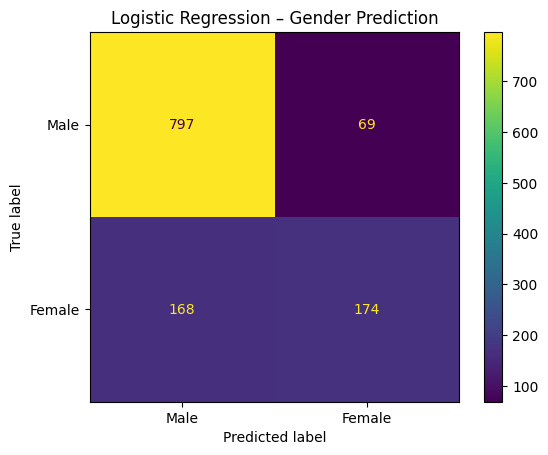

In [63]:
log_reg = LogisticRegression(max_iter=500)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

labels_gender = [1, 0]

cm = confusion_matrix(y_test, y_pred, labels=labels_gender)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot()
plt.title("Logistic Regression – Gender Prediction")
plt.savefig("plots/lr_gender_final.png", bbox_inches="tight")
plt.show()

Random Forest Accuracy: 0.7831125827814569
              precision    recall  f1-score   support

           0       0.72      0.38      0.50       342
           1       0.79      0.94      0.86       866

    accuracy                           0.78      1208
   macro avg       0.76      0.66      0.68      1208
weighted avg       0.77      0.78      0.76      1208



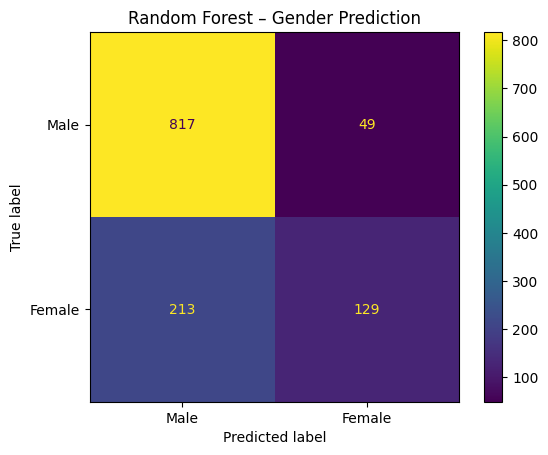

In [64]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=labels_gender)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot()
plt.title("Random Forest – Gender Prediction")
plt.savefig("plots/rf_gender_final.png", bbox_inches="tight")
plt.show()

In [65]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
18,Romance,0.069542
5,Action,0.036773
45,latent_5,0.035256
19,Sci-Fi,0.032647
20,Thriller,0.020917
6,Adventure,0.016941
15,Horror,0.015696
16,Musical,0.015691
44,latent_4,0.015683
22,Western,0.015079


### Age

In [66]:
X = combined_features
y = data["age_group"]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.6374172185430463
              precision    recall  f1-score   support

       25-44       0.65      0.80      0.72       658
     45_plus       0.61      0.48      0.54       285
    under_25       0.61      0.39      0.48       265

    accuracy                           0.64      1208
   macro avg       0.62      0.56      0.58      1208
weighted avg       0.63      0.64      0.62      1208



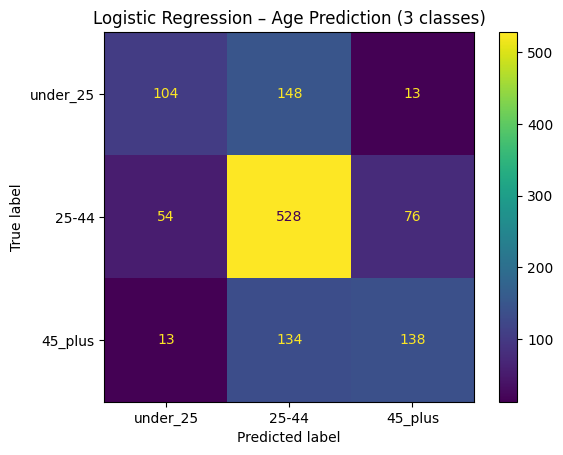

In [69]:
log_reg = LogisticRegression(max_iter=500)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Logistic Regression – Age Prediction (3 classes)")
plt.savefig("plots/lr_final.png", bbox_inches="tight")
plt.show()

Random Forest Accuracy: 0.597682119205298
              precision    recall  f1-score   support

       25-44       0.58      0.93      0.72       658
     45_plus       0.67      0.23      0.34       285
    under_25       0.70      0.17      0.27       265

    accuracy                           0.60      1208
   macro avg       0.65      0.44      0.44      1208
weighted avg       0.63      0.60      0.53      1208



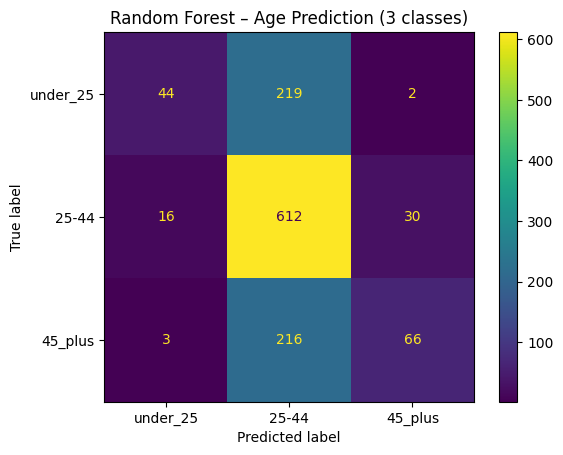

In [70]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Random Forest – Age Prediction (3 classes)")
plt.savefig("plots/rf_final.png", bbox_inches="tight")
plt.show()

In [71]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
44,latent_3,0.042427
52,latent_11,0.021052
22,Western,0.018312
49,latent_8,0.016724
7,Animation,0.015745
8,Children's,0.015369
12,Drama,0.014959
51,latent_10,0.014938
2,std_rating,0.014918
42,latent_1,0.014570


## Final Project Summary

The project explored whether user demographics can be inferred from movie rating behavior using three different feature representations: explicit genre-based features, latent embeddings derived from matrix factorization, and a combination of both.

For **gender prediction**, all approaches achieved similar overall accuracy (around 75–80%), but the differences appear in how well they handle class imbalance. Genre-based features and embeddings performed comparably, with embeddings slightly improving ROC–AUC, indicating a better capture of underlying preference structure. However, the best results were obtained using the **combined feature set**, where Logistic Regression reached about **80% accuracy** and showed the most balanced performance across classes. This suggests that gender-related signals are distributed across both explicit preferences (genres) and latent behavioral patterns, and neither representation alone is sufficient.

For **age prediction**, the differences between approaches were more pronounced. Genre-based features alone performed relatively poorly, especially in multi-class settings, indicating that explicit genre preferences are not strong indicators of age. In contrast, **latent embeddings provided a clear improvement**, capturing more subtle patterns in user behavior and leading to significantly better performance. The combined feature approach again yielded the best results, but the improvement over embeddings alone was modest. This suggests that, unlike gender, age-related patterns are primarily encoded in the latent structure of user preferences rather than in explicit genre statistics.

Across all experiments, **Logistic Regression consistently matched or outperformed Random Forest**, particularly when using embeddings or combined features. This indicates that the learned feature spaces—especially those derived from matrix factorization—are largely linearly separable, and do not benefit significantly from more complex non-linear models.

Overall, the results point to a clear conclusion:

* For **gender prediction**, the optimal approach is a **combination of genre-based features and embeddings**, as both contribute complementary information.
* For **age prediction**, **latent embeddings are the dominant representation**, with combined features offering only marginal additional gains.

This highlights an important distinction: while gender differences are reflected in both explicit and implicit preference patterns, age differences are primarily captured through deeper, latent structures in user behavior.
